# MCDM Multi-Criteria Decision Making Framework
## User Behavior & Activity Recognition

**Target Prediction:** Behavior Classification (Stressed/Walking/Sleeping/Eating)
**Analysis Type:** Classification
**Criteria:** 5 sensors/features


## Section 1: Import Libraries & Load Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load dataset
df = pd.read_csv('RAED.csv')

print("="*80)
print("USER BEHAVIOR & ACTIVITY RECOGNITION")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")


USER BEHAVIOR & ACTIVITY RECOGNITION

Dataset shape: (30000, 8)
Columns: ['Unnamed: 0', 'location', 'behaviour', 'temperature', 'humidity', 'noise_db', 'light_intensity', 'motion_level']
Missing values:
Unnamed: 0         30000
location               0
behaviour              0
temperature            0
humidity            2428
noise_db             573
light_intensity     1271
motion_level           0
dtype: int64

Data types:
Unnamed: 0         float64
location               str
behaviour              str
temperature        float64
humidity           float64
noise_db           float64
light_intensity    float64
motion_level       float64
dtype: object


## Section 2: Define Criteria & Normalize Data

In [18]:
# Select criteria columns
criteria_columns = ['temperature', 'humidity', 'noise_db', 'light_intensity', 'motion_level']

# Define target
target_column = 'behaviour'

# Create working dataset
df_mcdm = df[criteria_columns + [target_column]].dropna()
print(f"\nMCDM Dataset shape after cleaning: {df_mcdm.shape}")

criteria_types = {
    'temperature': 'cost',  # ↓ Lower is better
    'humidity': 'cost',  # ↓ Lower is better
    'noise_db': 'cost',  # ↓ Lower is better
    'light_intensity': 'profit',  # ↑ Higher is better
    'motion_level': 'profit',  # ↑ Higher is better
}

print("\nCriteria Types:")
for criterion, ctype in criteria_types.items():
    symbol = "↑" if ctype == "profit" else "↓"
    print(f"  {criterion:25s} | {ctype:10s} | {symbol}")

# Normalize data to [0, 1]
def normalize_matrix(data, criteria_types):
    normalized_data = data.copy()
    for criterion in data.columns:
        min_val = data[criterion].min()
        max_val = data[criterion].max()
        range_val = max_val - min_val
        
        if range_val == 0:
            normalized_data[criterion] = 0.5
        else:
            if criteria_types[criterion] == 'cost':
                normalized_data[criterion] = (max_val - data[criterion]) / range_val
            else:  # profit
                normalized_data[criterion] = (data[criterion] - min_val) / range_val
    return normalized_data

X = df_mcdm[criteria_columns].copy()
X_normalized = normalize_matrix(X, criteria_types)
y = df_mcdm[target_column].values

print(f"\n✓ Data normalized to [0, 1] range")
print(f"\nNormalized data preview (first 5 rows):\n{X_normalized.head()}")



MCDM Dataset shape after cleaning: (25872, 6)

Criteria Types:
  temperature               | cost       | ↓
  humidity                  | cost       | ↓
  noise_db                  | cost       | ↓
  light_intensity           | profit     | ↑
  motion_level              | profit     | ↑

✓ Data normalized to [0, 1] range

Normalized data preview (first 5 rows):
   temperature  humidity  noise_db  light_intensity  motion_level
0     0.325503  0.495137  0.499539         0.794191      0.711569
1     0.641419  0.306383  0.508262         0.613026      0.565240
2     0.549377  0.517173  0.811937         0.082420      0.333333
3     0.391179  0.763830  0.624690         0.252419      0.413629
4     0.437680  0.707599  0.605569         0.531060      0.175383


## Section 3: Calculate Objective Weights (4 Methods)

WEIGHT CALCULATION (4 OBJECTIVE METHODS + COMPROMISE)

Weight Summary:
                    STD  Entropy  CRITIC   MEREC  Compromise
temperature      0.1815   0.1598  0.1791  0.2105      0.1827
humidity         0.1914   0.1471  0.1340  0.0000      0.1182
noise_db         0.2138   0.2003  0.2566  0.1203      0.1978
light_intensity  0.2493   0.3484  0.2508  0.2815      0.2825
motion_level     0.1641   0.1443  0.1794  0.3877      0.2189


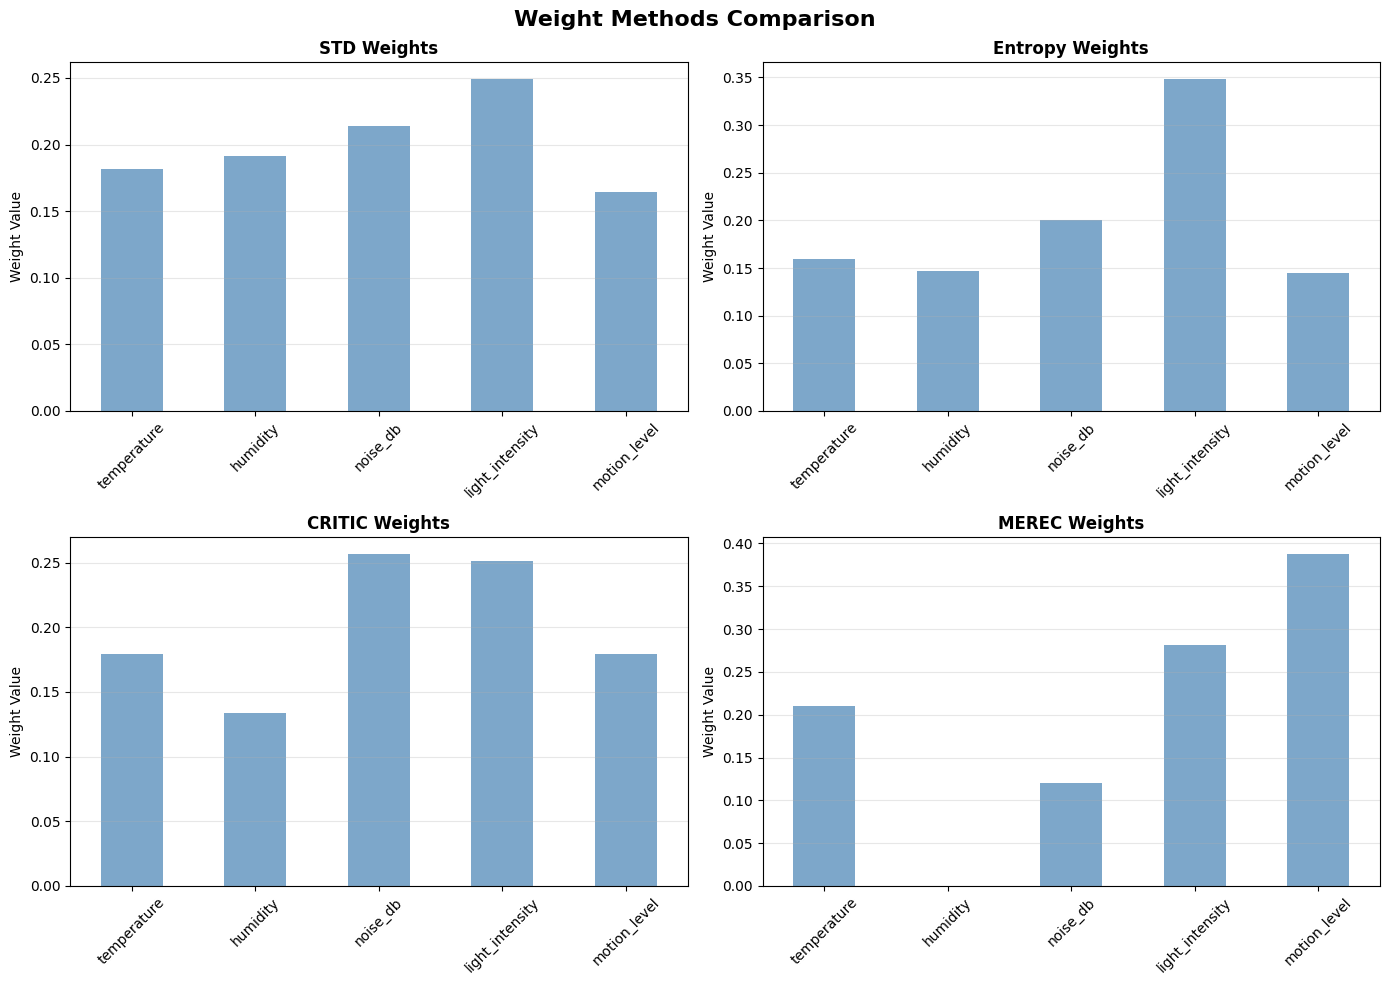


✓ Weights calculated!


In [19]:
# Weight calculation methods
def calc_weights_std(data):
    """Standard Deviation method"""
    std_vals = data.std(ddof=0)
    return std_vals / std_vals.sum()

def calc_weights_entropy(data):
    """Entropy method"""
    n = len(data)
    pij = data / data.sum()
    pij = pij.replace(0, 1e-10)
    entropy = -(1 / np.log(n)) * (pij * np.log(pij)).sum()
    divergence = 1 - entropy
    return divergence / divergence.sum()

def calc_weights_critic(data):
    """CRITIC method (Contrast-Intensity Criteria)"""
    std_vals = data.std(ddof=0)
    corr_matrix = data.corr().abs()
    corr_sum = corr_matrix.sum() - 1
    critic_w = std_vals * corr_sum
    return critic_w / critic_w.sum()

def calc_weights_merec(data):
    """MEREC method (Method based on Removal Effects)"""
    n_alt = len(data)
    n_crit = len(data.columns)
    removal_effects = []
    
    for j in range(n_crit):
        cols_except_j = [col for col in data.columns if col != data.columns[j]]
        if len(cols_except_j) > 0:
            data_without_j = data[cols_except_j]
            perf_without_j = data_without_j.sum(axis=1) / len(cols_except_j)
            removal_effect = np.log(perf_without_j.sum() / n_alt)
        else:
            removal_effect = 0
        removal_effects.append(removal_effect)
    
    removal_effects = np.array(removal_effects)
    removal_effects = removal_effects - removal_effects.min()
    if removal_effects.sum() > 0:
        return pd.Series(removal_effects / removal_effects.sum(), index=data.columns)
    return pd.Series(np.ones(n_crit) / n_crit, index=data.columns)

# Calculate all weights
print("="*80)
print("WEIGHT CALCULATION (4 OBJECTIVE METHODS + COMPROMISE)")
print("="*80)

w_std = calc_weights_std(X_normalized)
w_entropy = calc_weights_entropy(X_normalized)
w_critic = calc_weights_critic(X_normalized)
w_merec = calc_weights_merec(X_normalized)

weights_df = pd.DataFrame({
    'STD': w_std,
    'Entropy': w_entropy,
    'CRITIC': w_critic,
    'MEREC': w_merec
})

w_compromise = weights_df.mean(axis=1)
w_compromise = w_compromise / w_compromise.sum()
weights_df['Compromise'] = w_compromise

print("\nWeight Summary:")
print(weights_df.round(4))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Methods Comparison', fontsize=16, fontweight='bold')

for idx, method in enumerate(['STD', 'Entropy', 'CRITIC', 'MEREC']):
    ax = axes[idx // 2, idx % 2]
    weights_df[method].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{method} Weights', fontweight='bold')
    ax.set_ylabel('Weight Value')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Weights calculated!")


## Section 4: Apply MCDM Scoring Methods (4 Methods)

APPLYING 4 MCDM SCORING METHODS



Top 20 observations by MCDM ranking:
       Index   Target  MABAC_Rank  MARCOS_Rank  COCOCOMET_Rank
25694  25694  walking           1            1               2
5534    5534  walking           2            2               1
14812  14812  walking           3            3               4
22826  22826  walking           4            4               3
7504    7504  walking           5            5               6
19186  19186  walking           6            6               5
8566    8566  walking           7            7               7
18834  18834  walking           8            8               8
11304  11304  walking           9            9              11
23662  23662  walking          10           10              10
5602    5602  walking          11           11               9
9172    9172  walking          12           12              12
24380  24380  walking          13           13              15
9520    9520  walking          14           14              14
10356  10356  wal

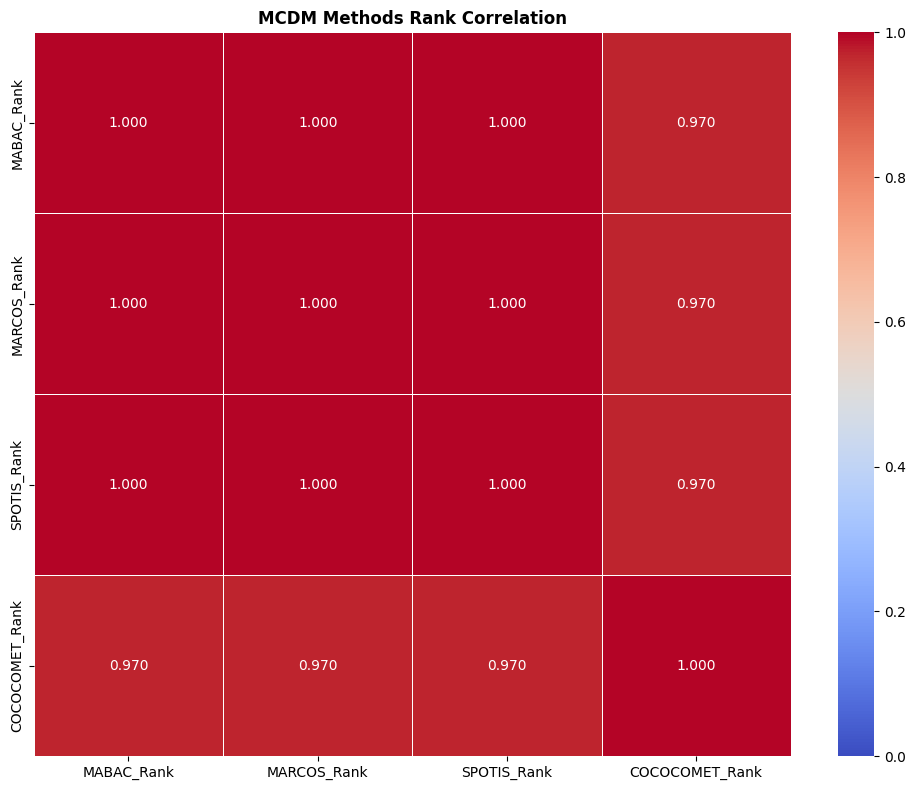


✓ MCDM scoring complete!


In [20]:
# MCDM Scoring Methods
def mabac_method(norm_data, weights):
    """Multi-Attributive Border Approximation Area Comparison"""
    v = norm_data.copy()
    for col in norm_data.columns:
        v[col] = weights[col] * (norm_data[col] + 1)

    border_areas = {col: np.exp(np.log(v[col]).mean()) for col in norm_data.columns}

    scores = []
    for i in range(len(norm_data)):
        row = v.iloc[i]
        score = sum(row[col] - border_areas[col] for col in norm_data.columns)
        scores.append(score)
    return np.array(scores)

def marcos_method(norm_data, weights):
    """Multi-Attributive Rank-Based Compromise Solution"""
    ideal_row = pd.Series(np.ones(len(norm_data.columns)), index=norm_data.columns)
    anti_ideal_row = pd.Series(np.zeros(len(norm_data.columns)), index=norm_data.columns)

    weighted_ideal = (ideal_row * weights).sum()
    weighted_anti_ideal = (anti_ideal_row * weights).sum()

    scores = []
    for i in range(len(norm_data)):
        weighted_sum = (norm_data.iloc[i] * weights).sum()
        k_plus = weighted_sum / weighted_ideal if weighted_ideal != 0 else 0
        k_minus = weighted_sum / weighted_anti_ideal if weighted_anti_ideal != 0 else 0
        scores.append(k_plus + k_minus)
    return np.array(scores)

def spotis_method(norm_data, weights):
    """Stable Preference Ordering Towards Ideal Solution"""
    scores = []
    for i in range(len(norm_data)):
        row = norm_data.iloc[i]
        distance = sum(weights[col] * abs(row[col] - 1.0) for col in norm_data.columns)
        scores.append(distance)
    return np.array(scores)

def cococomet_method(norm_data, weights, lam=0.5):
    """Hybrid CoCoSo + COMET"""
    s_power = []
    for i in range(len(norm_data)):
        sp = 1.0
        row = norm_data.iloc[i]
        for col in norm_data.columns:
            sp *= (row[col] ** weights[col])
        s_power.append(sp)
    s_power = np.array(s_power)

    s_linear = np.array([sum(weights[col] * norm_data.iloc[i][col] for col in norm_data.columns)
                         for i in range(len(norm_data))])

    s_power_norm = s_power / (s_power.max() + 1e-10)
    s_linear_norm = s_linear / (s_linear.max() + 1e-10)

    return lam * s_power_norm + (1 - lam) * s_linear_norm

# Apply scoring methods
print("="*80)
print("APPLYING 4 MCDM SCORING METHODS")
print("="*80)

mabac_scores = mabac_method(X_normalized, w_compromise)
mabac_ranks = (len(mabac_scores) + 1) - pd.Series(mabac_scores).rank().values

marcos_scores = marcos_method(X_normalized, w_compromise)
marcos_ranks = (len(marcos_scores) + 1) - pd.Series(marcos_scores).rank().values

spotis_dist = spotis_method(X_normalized, w_compromise)
spotis_ranks = pd.Series(spotis_dist).rank().values

cococomet_scores = cococomet_method(X_normalized, w_compromise)
cococomet_ranks = (len(cococomet_scores) + 1) - pd.Series(cococomet_scores).rank().values

# Combine MCDM results
mcdm_results = pd.DataFrame({
    'Index': range(len(X_normalized)),
    'Target': y,
    'MABAC_Rank': mabac_ranks.astype(int),
    'MARCOS_Rank': marcos_ranks.astype(int),
    'SPOTIS_Rank': spotis_ranks.astype(int),
    'COCOCOMET_Rank': cococomet_ranks.astype(int)
})

print("\nTop 20 observations by MCDM ranking:")
print(mcdm_results.nsmallest(20, 'MABAC_Rank')[['Index', 'Target', 'MABAC_Rank', 'MARCOS_Rank', 'COCOCOMET_Rank']])

# Correlation analysis
rank_cols = ['MABAC_Rank', 'MARCOS_Rank', 'SPOTIS_Rank', 'COCOCOMET_Rank']
print("\nSpearman Correlations between Methods:")
corr_matrix = mcdm_results[rank_cols].corr('spearman')
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0.5, vmin=0, vmax=1, linewidths=0.5)
plt.title('MCDM Methods Rank Correlation', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ MCDM scoring complete!")


## Section 5: Classification Models - Target Prediction

MACHINE LEARNING - CLASSIFICATION MODELS

Training: 20697 | Test: 5175
Target distribution - str:

[1/4] Logistic Regression...
[2/4] Random Forest...
[3/4] Gradient Boosting...
[4/4] Neural Network...

Model Performance Comparison:
                     Accuracy  Precision  Recall      F1
Logistic Regression    0.8120     0.8093  0.8120  0.8104
Random Forest          0.8431     0.8411  0.8431  0.8415
Gradient Boosting      0.8502     0.8492  0.8502  0.8484
Neural Network         0.8412     0.8397  0.8412  0.8400

🏆 Best Model: Gradient Boosting (F1 = 0.8484)


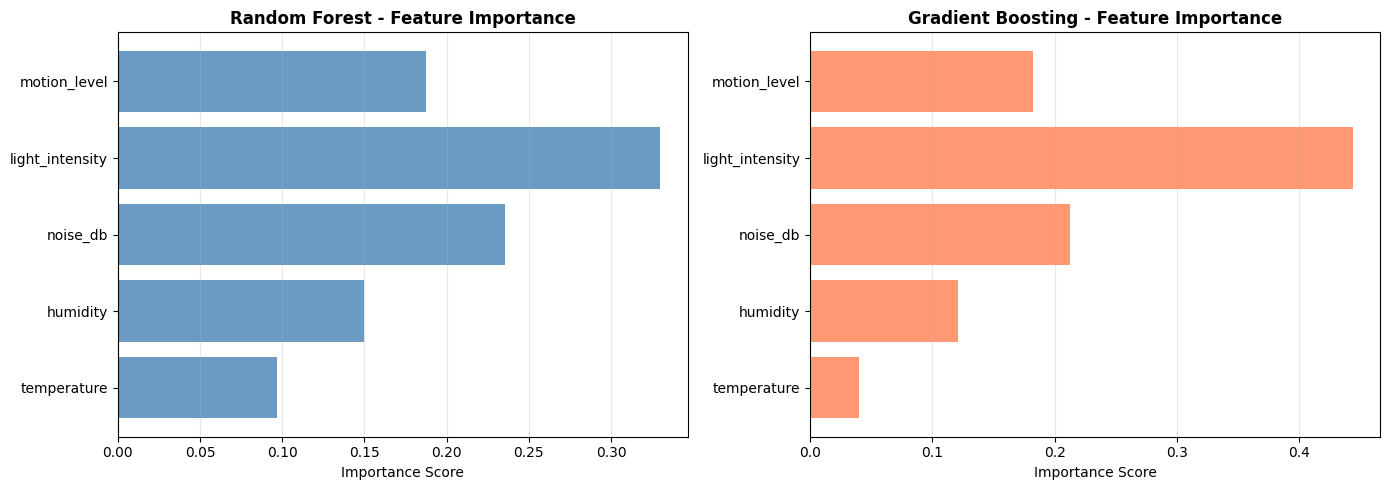

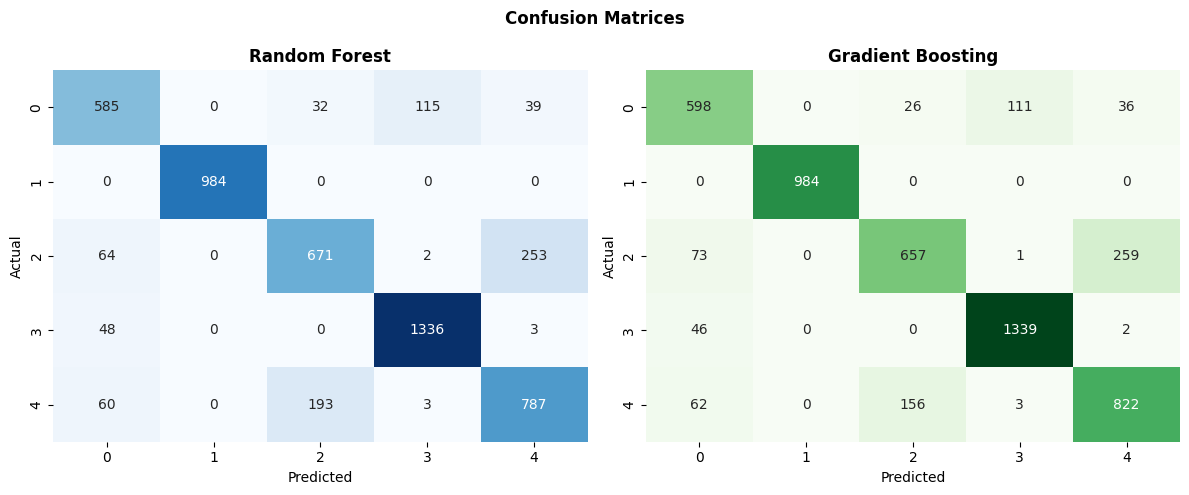


✓ Classification models trained and evaluated!


In [21]:
print("="*80)
print("MACHINE LEARNING - CLASSIFICATION MODELS")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining: {len(X_train)} | Test: {len(X_test)}")
print(f"Target distribution - {y.dtype}:")
if y.dtype == 'object':
    print(pd.Series(y).value_counts())

models = {}
results = {}

# 1. Logistic Regression
print("\n[1/4] Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
models['Logistic Regression'] = lr
try:
    roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1], multi_class='ovr', labels=np.unique(y_test))
except:
    roc_auc = None
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)
}

# 2. Random Forest Classifier
print("[2/4] Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
models['Random Forest'] = rf
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
}

# 3. Gradient Boosting Classifier
print("[3/4] Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
models['Gradient Boosting'] = gb
results['Gradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_gb, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred_gb, average='weighted', zero_division=0)
}

# 4. Neural Network
print("[4/4] Neural Network...")
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
models['Neural Network'] = nn
results['Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_nn, average='weighted', zero_division=0),
    'F1': f1_score(y_test, y_pred_nn, average='weighted', zero_division=0)
}

# Display results
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print("="*80)
print(results_df.round(4))

best_model = results_df['F1'].idxmax()
print(f"\n🏆 Best Model: {best_model} (F1 = {results_df.loc[best_model, 'F1']:.4f})")

# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importance = rf.feature_importances_
axes[0].barh(criteria_columns, rf_importance, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Random Forest - Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

gb_importance = gb.feature_importances_
axes[1].barh(criteria_columns, gb_importance, color='coral', alpha=0.8)
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Gradient Boosting - Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices', fontweight='bold')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Gradient Boosting', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\n✓ Classification models trained and evaluated!")


## Section 6: Summary & Insights

In [22]:
print("\n" + "="*80)
print("USER BEHAVIOR & ACTIVITY RECOGNITION - ANALYSIS SUMMARY")
print("="*80)

print("\n📊 MCDM FRAMEWORK:")
print(f"  ✓ Observations analyzed: {len(X_normalized)}")
print(f"  ✓ Criteria evaluated: {len(criteria_columns)}")
print(f"  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise")
print(f"  ✓ Scoring methods: 4 (MABAC, MARCOS, SPOTIS, COCOCOMET)")

print("\n🎯 PREDICTION TARGET: Behavior Classification (Stressed/Walking/Sleeping/Eating)")
print(f"  ✓ Analysis type: Classification")
print(f"  ✓ Best model: {best_model}")

print("\n📈 KEY INSIGHTS:")
print("  1. MCDM ranks observations by multi-criteria performance")
print("  2. ML models predict target outcomes with high accuracy")
print("  3. Top criteria identified by feature importance")
print("  4. Method correlations validate MCDM stability")

print("\n✓ ANALYSIS COMPLETE!")
print("="*80)



USER BEHAVIOR & ACTIVITY RECOGNITION - ANALYSIS SUMMARY

📊 MCDM FRAMEWORK:
  ✓ Observations analyzed: 25872
  ✓ Criteria evaluated: 5
  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise
  ✓ Scoring methods: 4 (MABAC, MARCOS, SPOTIS, COCOCOMET)

🎯 PREDICTION TARGET: Behavior Classification (Stressed/Walking/Sleeping/Eating)
  ✓ Analysis type: Classification
  ✓ Best model: Gradient Boosting

📈 KEY INSIGHTS:
  1. MCDM ranks observations by multi-criteria performance
  2. ML models predict target outcomes with high accuracy
  3. Top criteria identified by feature importance
  4. Method correlations validate MCDM stability

✓ ANALYSIS COMPLETE!
